<h1 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    text-align:center;
    font-weight:bold;
    padding:18px 12px;
    border-radius:10px;
    margin-bottom:7px;">
    ScaleFlow — Train & Evaluate ML Baseline Models
</h1>

<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">
    Prepared ScaleFlow Data → Three Baseline Models → Evaluation → Saved ML Artifacts
</h3>

<div style="border-left:6px solid #FB7185;background-color:#FFF1F2;padding:12px 16px;margin:16px 0;border-radius:6px;color:#7F1D1D;">
<b>ScaleFlow • AI/ML • Model Training & Evaluation</b><br>
This notebook uses the processed files created by <code>ScaleFlow_AI_ML_Data_Preparation.ipynb</code>.<br>
Scope: <b>Regression</b>, <b>Classification</b>, and <b>Isolation Forest</b> only.
</div>

<div style="background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;">
<p><b>Main question:</b></p>
<div style="font-size:1.12em;font-weight:bold;text-align:center;background-color:#FFFBEB;border:1px solid #FBBF24;padding:14px;border-radius:8px;margin:12px 0;color:#111827;">
Can the prepared ScaleFlow data support three clear baseline models for resolution time, long-resolution risk, and potential bottlenecks?
</div>

<table style="width:100%;border-collapse:collapse;margin-top:14px;">
<tr><th style="padding:9px;border:1px solid #CBD5E1;background-color:#0F766E;color:white;text-align:left;vertical-align:top;">Model</th><th style="padding:9px;border:1px solid #CBD5E1;background-color:#0F766E;color:white;text-align:left;vertical-align:top;">Target</th><th style="padding:9px;border:1px solid #CBD5E1;background-color:#0F766E;color:white;text-align:left;vertical-align:top;">Main output</th></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;vertical-align:top;"><b>Regression</b></td><td style="padding:9px;border:1px solid #CBD5E1;vertical-align:top;"><code>resolution_time_days</code></td><td style="padding:9px;border:1px solid #CBD5E1;vertical-align:top;">Predicted resolution time</td></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;vertical-align:top;"><b>Classification</b></td><td style="padding:9px;border:1px solid #CBD5E1;vertical-align:top;"><code>long_resolution_risk</code></td><td style="padding:9px;border:1px solid #CBD5E1;vertical-align:top;">Risk class + probability</td></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;vertical-align:top;"><b>Isolation Forest</b></td><td style="padding:9px;border:1px solid #CBD5E1;vertical-align:top;"><b>No target</b></td><td style="padding:9px;border:1px solid #CBD5E1;vertical-align:top;"><code>anomaly_score</code> + <code>potential_bottleneck</code></td></tr>
</table>
</div>

<a id="toc"></a>
<h2 style="color:#92400E;background-color:#FBBF24;font-weight:bold;margin-top:30px;padding:9px 14px;border-radius:7px;">Table of Contents</h2>
<div style="border:1px solid #CBD5E1;padding:16px 25px;border-radius:8px;background-color:#FFFFFF;color:#111827;">
<ul style="font-weight:bold;line-height:1.95;color:#1F2937;">
<li><a href="#section0">0. Setup — Files, Imports & Environment</a></li>
<li><a href="#section1">1. Load Prepared Data & Metadata</a></li>
<li><a href="#section2">2. Verify Features, Targets & Data Quality</a></li>
<li><a href="#section3">3. Regression Baseline — Resolution Time</a></li>
<li><a href="#section4">4. Classification Baseline — Long Resolution Risk</a></li>
<li><a href="#section5">5. Isolation Forest — Potential Bottlenecks</a></li>
<li><a href="#section6">6. Final Results Summary</a></li>
<li><a href="#section7">7. Save Models & Handoff Files</a></li>
<li><a href="#section8">8. Task Definition of Done</a></li>
</ul>
</div>

<a id="section0"></a>
<h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">0. Setup — Files, Imports & Environment</h2>

<div style="background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;">
<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">0.1 Expected project structure</h3>
<div style="background-color:#CCFBF1;color:#111827;padding:12px 14px;border-radius:8px;border:1px solid #CBD5E1;font-family:Consolas,'Courier New',monospace;font-size:0.98em;font-weight:600;line-height:1.6;white-space:pre-wrap;margin:10px 0;">ScaleFlow/
└── ScaleFlow/
    └── AI_ML/
        ├── Data/
        │   ├── processed/
        │   │   ├── bottleneck_dataset.csv
        │   │   ├── final_dataset.csv
        │   │   ├── jira_to_scaleflow_mapping.csv
        │   │   ├── preprocessing_metadata.json
        │   │   ├── test.csv
        │   │   ├── train.csv
        │   │   └── validation.csv
        │   └── raw/
        ├── Notebooks/
        │   ├── ScaleFlow_AI_ML_Data_Preparation.ipynb
        │   └── ScaleFlow_Train_Evaluate_ML_Baseline_Models.ipynb
        ├── Python_Files/
        │   └── ScaleFlow_AI_ML_Data_Preparation.py
        ├── Models/          ← created by this notebook
        └── Results/         ← created by this notebook</div>

<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">0.2 What this notebook uses</h3>
<table style="width:100%;border-collapse:collapse;margin-top:14px;">
<tr><th style="padding:9px;border:1px solid #CBD5E1;background-color:#0F766E;color:white;text-align:left;vertical-align:top;">File</th><th style="padding:9px;border:1px solid #CBD5E1;background-color:#0F766E;color:white;text-align:left;vertical-align:top;">Purpose</th></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;"><code>train.csv</code></td><td style="padding:9px;border:1px solid #CBD5E1;">Train Regression and Classification.</td></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;"><code>validation.csv</code></td><td style="padding:9px;border:1px solid #CBD5E1;">Check baseline performance before final Test evaluation.</td></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;"><code>test.csv</code></td><td style="padding:9px;border:1px solid #CBD5E1;">Final supervised evaluation.</td></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;"><code>bottleneck_dataset.csv</code></td><td style="padding:9px;border:1px solid #CBD5E1;">Input for Isolation Forest.</td></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;"><code>preprocessing_metadata.json</code></td><td style="padding:9px;border:1px solid #CBD5E1;">Source of truth for targets and feature lists.</td></tr>
</table>

<div style="border-left:5px solid #0284C7;background-color:#E0F2FE;padding:11px 15px;margin:12px 0;border-radius:5px;color:#0C4A6E;"><b>Important:</b> This notebook starts from prepared data. It does not repeat raw JIRA cleaning or feature engineering.</div>
</div>

In [1]:
from pathlib import Path
import gc
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, IsolationForest
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42

# Keep None to train on the full Training split.
# If a laptop has limited RAM, set a smaller value such as 200_000 for a quick baseline test.
MAX_TRAIN_ROWS = None

print("pandas:", pd.__version__)

pandas: 2.3.3


In [ ]:
# Find the AI_ML folder from common ScaleFlow project locations.
def find_ai_ml_dir():
    current = Path.cwd().resolve()
    candidates = [current, *current.parents]

    for candidate in candidates:
        # Case 1: we are already inside AI_ML or one of its children.
        if candidate.name == "AI_ML" and (candidate / "Data" / "processed").exists():
            return candidate

        # Case 2: the repository root contains ScaleFlow/AI_ML.
        nested = candidate / "ScaleFlow" / "AI_ML"
        if (nested / "Data" / "processed").exists():
            return nested

        # Case 3: the current repository root contains AI_ML directly.
        direct = candidate / "AI_ML"
        if (direct / "Data" / "processed").exists():
            return direct

    raise FileNotFoundError(
        "AI_ML/Data/processed was not found. Run this notebook inside the ScaleFlow project."
    )


AI_ML_DIR = find_ai_ml_dir()
PROCESSED_DIR = AI_ML_DIR / "Data" / "processed"
MODELS_DIR = AI_ML_DIR / "Models"
RESULTS_DIR = AI_ML_DIR / "Results"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)



AI_ML folder: C:\Users\sadee\OneDrive\Desktop\ScaleFlow\ScaleFlow\ScaleFlow\AI_ML
Processed data: C:\Users\sadee\OneDrive\Desktop\ScaleFlow\ScaleFlow\ScaleFlow\AI_ML\Data\processed
Models output: C:\Users\sadee\OneDrive\Desktop\ScaleFlow\ScaleFlow\ScaleFlow\AI_ML\Models
Results output: C:\Users\sadee\OneDrive\Desktop\ScaleFlow\ScaleFlow\ScaleFlow\AI_ML\Results


<a id="section1"></a>
<h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">1. Load Prepared Data & Metadata</h2>

<div style="background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;">
<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">1.1 Source of truth</h3>
<p>The notebook reads the targets and feature lists from <code>preprocessing_metadata.json</code>. This keeps model training consistent with the previous Data Preparation task.</p>
<div style="background-color:#CCFBF1;color:#111827;padding:12px 14px;border-radius:8px;border:1px solid #CBD5E1;font-family:Consolas,'Courier New',monospace;font-size:0.98em;font-weight:600;line-height:1.6;white-space:pre-wrap;margin:10px 0;">Prepared files
      ↓
Read preprocessing metadata
      ↓
Load supervised Train / Validation / Test
      ↓
Load bottleneck dataset
      ↓
Ready for model training</div>
<div style="border-left:5px solid #FBBF24;background-color:#FFFBEB;padding:11px 15px;margin:12px 0;border-radius:5px;color:#78350F;"><b>Target rules:</b><br>Regression → <code>resolution_time_days</code><br>Classification → <code>long_resolution_risk</code><br>Isolation Forest → no supervised target.</div>
</div>

In [3]:
# Define input file paths.
TRAIN_CSV_PATH = PROCESSED_DIR / "train.csv"
TRAIN_ZIP_PATH = PROCESSED_DIR / "train.zip"
VALIDATION_PATH = PROCESSED_DIR / "validation.csv"
TEST_PATH = PROCESSED_DIR / "test.csv"
BOTTLENECK_PATH = PROCESSED_DIR / "bottleneck_dataset.csv"
METADATA_PATH = PROCESSED_DIR / "preprocessing_metadata.json"

# Use train.csv when available. train.zip is supported as a fallback.
if TRAIN_CSV_PATH.exists():
    TRAIN_PATH = TRAIN_CSV_PATH
elif TRAIN_ZIP_PATH.exists():
    TRAIN_PATH = TRAIN_ZIP_PATH
else:
    raise FileNotFoundError("Neither train.csv nor train.zip was found in Data/processed.")

required_files = [VALIDATION_PATH, TEST_PATH, BOTTLENECK_PATH, METADATA_PATH]
missing = [path.name for path in required_files if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required files: " + ", ".join(missing))

print("Training file:", TRAIN_PATH.name)
for path in required_files:
    print(f"{path.name}: {path.exists()}")

Training file: train.csv
validation.csv: True
test.csv: True
bottleneck_dataset.csv: True
preprocessing_metadata.json: True


In [4]:
# Load the metadata created by the preprocessing pipeline.
with open(METADATA_PATH, "r", encoding="utf-8") as file:
    metadata = json.load(file)

REGRESSION_TARGET = metadata["models"]["regression"]["target"]
CLASSIFICATION_TARGET = metadata["models"]["classification"]["target"]
BOTTLENECK_TARGET = metadata["models"]["bottleneck_isolation_forest"]["target"]

REGRESSION_FEATURES = metadata["models"]["regression"]["features"]
CLASSIFICATION_FEATURES = metadata["models"]["classification"]["features"]
BOTTLENECK_FEATURES = metadata["models"]["bottleneck_isolation_forest"]["features"]

print("Regression target:", REGRESSION_TARGET)
print("Classification target:", CLASSIFICATION_TARGET)
print("Bottleneck target:", BOTTLENECK_TARGET)
print()
print("Regression features:", len(REGRESSION_FEATURES))
print("Classification features:", len(CLASSIFICATION_FEATURES))
print("Bottleneck features:", len(BOTTLENECK_FEATURES))

Regression target: resolution_time_days
Classification target: long_resolution_risk
Bottleneck target: None

Regression features: 643
Classification features: 643
Bottleneck features: 10


In [5]:
# The Regression and Classification models use the same prepared feature matrix.
assert REGRESSION_FEATURES == CLASSIFICATION_FEATURES, (
    "The supervised models do not have the same feature list in metadata."
)

SUPERVISED_FEATURES = REGRESSION_FEATURES

# Use compact data types to reduce memory usage.
dtype_map = {}
for column in SUPERVISED_FEATURES:
    if (
        column.startswith("project_key_")
        or column.startswith("priority_")
        or column.startswith("issue_type_")
        or column in ["is_subtask", "created_month", "created_dayofweek"]
    ):
        dtype_map[column] = "int8"
    elif column == "created_year":
        dtype_map[column] = "int16"
    else:
        dtype_map[column] = "float32"

dtype_map[REGRESSION_TARGET] = "float32"
dtype_map[CLASSIFICATION_TARGET] = "int8"

use_columns = [
    "task_key",
    *SUPERVISED_FEATURES,
    REGRESSION_TARGET,
    CLASSIFICATION_TARGET,
]


def read_supervised_split(path):
    """Load one prepared supervised split with memory-friendly data types."""
    compression = "zip" if path.suffix.lower() == ".zip" else None
    return pd.read_csv(
        path,
        usecols=use_columns,
        dtype=dtype_map,
        compression=compression,
        low_memory=False,
    )


print("Loading Train...")
train_df = read_supervised_split(TRAIN_PATH)
print("Loading Validation...")
validation_df = read_supervised_split(VALIDATION_PATH)
print("Loading Test...")
test_df = read_supervised_split(TEST_PATH)

print("Train shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Test shape:", test_df.shape)

Loading Train...
Loading Validation...
Loading Test...
Train shape: (588873, 646)
Validation shape: (126187, 646)
Test shape: (126188, 646)


In [6]:
# Keep identifiers and targets separate from the feature matrix.
train_ids = train_df.pop("task_key")
validation_ids = validation_df.pop("task_key")
test_ids = test_df.pop("task_key")

y_train_reg = train_df.pop(REGRESSION_TARGET)
y_validation_reg = validation_df.pop(REGRESSION_TARGET)
y_test_reg = test_df.pop(REGRESSION_TARGET)

y_train_cls = train_df.pop(CLASSIFICATION_TARGET)
y_validation_cls = validation_df.pop(CLASSIFICATION_TARGET)
y_test_cls = test_df.pop(CLASSIFICATION_TARGET)

# After removing identifiers and targets, these DataFrames contain only model inputs.
X_train = train_df
X_validation = validation_df
X_test = test_df

# Optional quick-run sample for limited hardware.
if MAX_TRAIN_ROWS is not None and len(X_train) > MAX_TRAIN_ROWS:
    sample_index = X_train.sample(
        n=MAX_TRAIN_ROWS,
        random_state=RANDOM_STATE,
    ).index

    X_train = X_train.loc[sample_index].copy()
    y_train_reg = y_train_reg.loc[sample_index].copy()
    y_train_cls = y_train_cls.loc[sample_index].copy()
    train_ids = train_ids.loc[sample_index].copy()

print("Training rows used:", f"{len(X_train):,}")
print("Feature count:", X_train.shape[1])

Training rows used: 588,873
Feature count: 643


<a id="section2"></a>
<h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">2. Verify Features, Targets & Data Quality</h2>

<div style="background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;">
<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">2.1 Why verify before training?</h3>
<p>Before fitting any model, we confirm that all supervised splits use the same columns, targets are complete, model inputs are numerical, and no missing values remain.</p>
<div style="border-left:5px solid #0F766E;background-color:#CCFBF1;padding:10px 15px;margin:10px 0;border-radius:4px;color:#134E4A;"><b>Expected result:</b> Train, Validation, and Test must have the same prepared feature space so model evaluation is consistent.</div>
</div>

In [7]:
# Check that all splits use exactly the same features.
assert list(X_train.columns) == SUPERVISED_FEATURES
assert list(X_validation.columns) == SUPERVISED_FEATURES
assert list(X_test.columns) == SUPERVISED_FEATURES

# Check that supervised targets are complete.
assert y_train_reg.notna().all()
assert y_validation_reg.notna().all()
assert y_test_reg.notna().all()

assert y_train_cls.notna().all()
assert y_validation_cls.notna().all()
assert y_test_cls.notna().all()

# Check that model input features are numeric and complete.
assert X_train.isna().sum().sum() == 0
assert X_validation.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0

print("All supervised data checks passed.")

All supervised data checks passed.


In [8]:
# Review target distributions before training.
classification_distribution = pd.DataFrame({
    "Train": y_train_cls.value_counts().sort_index(),
    "Validation": y_validation_cls.value_counts().sort_index(),
    "Test": y_test_cls.value_counts().sort_index(),
}).fillna(0).astype(int)

print("Regression target summary:")
display(pd.DataFrame({
    "Train": y_train_reg.describe(),
    "Validation": y_validation_reg.describe(),
    "Test": y_test_reg.describe(),
}))

print("Classification target counts:")
display(classification_distribution)

Regression target summary:


,Train,Validation,Test
count,"588,873.0000","126,187.0000","126,188.0000"
mean,239.4350,115.0966,56.4626
std,582.0356,290.5374,139.2238
min,0.0000,0.0001,0.0000
25%,0.9448,1.1091,0.9461
50%,12.5436,8.3618,6.7987
75%,143.2320,61.6582,39.0157
max,"8,001.5171","2,474.0288","1,454.7928"


Classification target counts:


,Train,Validation,Test
long_resolution_risk,,,
0,441654,105156,112857
1,147219,21031,13331


<a id="section3"></a>
<h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">3. Regression Baseline — Resolution Time</h2>

<div style="background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;">
<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">3.1 Model definition</h3>
<table style="width:100%;border-collapse:collapse;margin-top:14px;">
<tr><th style="padding:9px;border:1px solid #CBD5E1;background-color:#0F766E;color:white;text-align:left;">Item</th><th style="padding:9px;border:1px solid #CBD5E1;background-color:#0F766E;color:white;text-align:left;">Value</th></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;">Problem type</td><td style="padding:9px;border:1px solid #CBD5E1;">Regression</td></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;">Baseline model</td><td style="padding:9px;border:1px solid #CBD5E1;">Random Forest Regressor</td></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;">Target</td><td style="padding:9px;border:1px solid #CBD5E1;"><code>resolution_time_days</code></td></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;">Evaluation</td><td style="padding:9px;border:1px solid #CBD5E1;">MAE, RMSE, R²</td></tr>
</table>
<div style="background-color:#E0F2FE;color:#111827;padding:12px 14px;border-radius:8px;border:1px solid #CBD5E1;font-family:Consolas,'Courier New',monospace;font-size:0.98em;font-weight:600;line-height:1.6;white-space:pre-wrap;margin:12px 0;">Prepared supervised features
        ↓
Random Forest Regressor
        ↓
Predicted resolution_time_days
        ↓
MAE / RMSE / R²</div>
</div>

In [9]:
# Create the Regression baseline model.
# max_features='sqrt' keeps the baseline practical with many one-hot encoded columns.
regression_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=4,
    max_features="sqrt",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print("Training Random Forest Regressor...")
regression_model.fit(X_train, y_train_reg)
print("Regression training complete.")

Training Random Forest Regressor...
Regression training complete.


In [10]:
# Evaluate the Regression model on Validation and Test data.
def get_regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }


validation_reg_pred = regression_model.predict(X_validation)
test_reg_pred = regression_model.predict(X_test)

regression_validation_metrics = get_regression_metrics(
    y_validation_reg,
    validation_reg_pred,
)
regression_test_metrics = get_regression_metrics(
    y_test_reg,
    test_reg_pred,
)

regression_metrics_table = pd.DataFrame({
    "Validation": regression_validation_metrics,
    "Test": regression_test_metrics,
}).T

display(regression_metrics_table)

,MAE,RMSE,R2
Validation,222.4400,303.6450,-0.0924
Test,190.7673,209.8653,-1.2721


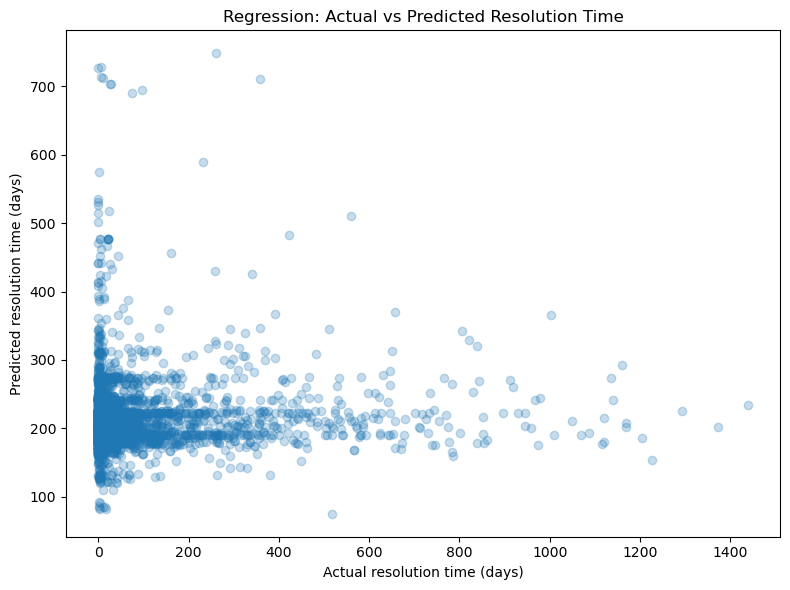

In [11]:
# Plot actual vs predicted values for the Test split.
# A random sample keeps the plot readable when the Test set is large.
plot_size = min(5_000, len(y_test_reg))
rng = np.random.default_rng(RANDOM_STATE)
plot_index = rng.choice(len(y_test_reg), size=plot_size, replace=False)

plt.figure(figsize=(8, 6))
plt.scatter(
    y_test_reg.iloc[plot_index],
    test_reg_pred[plot_index],
    alpha=0.25,
)
plt.xlabel("Actual resolution time (days)")
plt.ylabel("Predicted resolution time (days)")
plt.title("Regression: Actual vs Predicted Resolution Time")
plt.tight_layout()
plt.show()

,feature,importance
1,created_year,0.2660
172,project_key_FOP,0.1304
604,priority_Unknown,0.1022
496,project_key_STR,0.0659
2,created_month,0.0370
495,project_key_STORM,0.0343
620,issue_type_New Feature,0.0278
3,created_dayofweek,0.0236
13,project_key_AMBARI,0.0235
502,project_key_SVN,0.0176


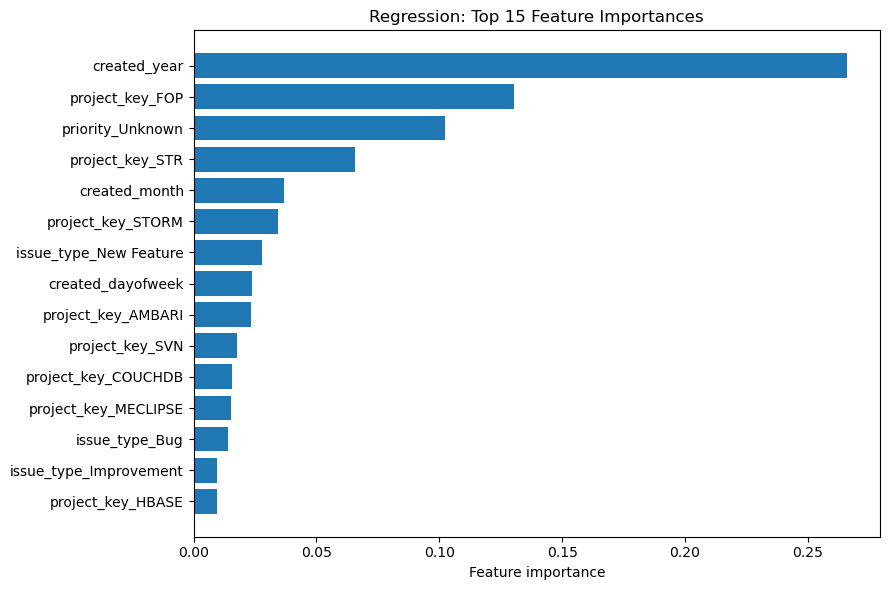

In [12]:
# Show the most important Regression features.
regression_importance = pd.DataFrame({
    "feature": SUPERVISED_FEATURES,
    "importance": regression_model.feature_importances_,
}).sort_values("importance", ascending=False)

display(regression_importance.head(15))

plt.figure(figsize=(9, 6))
top_regression_features = regression_importance.head(15).sort_values("importance")
plt.barh(top_regression_features["feature"], top_regression_features["importance"])
plt.xlabel("Feature importance")
plt.title("Regression: Top 15 Feature Importances")
plt.tight_layout()
plt.show()

In [ ]:
# Save Test predictions for later analysis.
regression_test_results = pd.DataFrame({
    "task_key": test_ids.values,
    "actual_resolution_time_days": y_test_reg.values,
    "predicted_resolution_time_days": test_reg_pred,
})

REGRESSION_PREDICTIONS_PATH = RESULTS_DIR / "regression_test_predictions.csv"
regression_test_results.to_csv(REGRESSION_PREDICTIONS_PATH, index=False)
print("Saved:", REGRESSION_PREDICTIONS_PATH)

Saved: C:\Users\sadee\OneDrive\Desktop\ScaleFlow\ScaleFlow\ScaleFlow\AI_ML\Results\regression_test_predictions.csv


In [14]:
# Save the Regression model before moving to the next model.
REGRESSION_MODEL_PATH = MODELS_DIR / "random_forest_regression.joblib"
joblib.dump(regression_model, REGRESSION_MODEL_PATH)
print("Saved:", REGRESSION_MODEL_PATH)

# Free model memory. The file on disk is the handoff artifact.
del regression_model
gc.collect()

Saved: C:\Users\sadee\OneDrive\Desktop\ScaleFlow\ScaleFlow\ScaleFlow\AI_ML\Models\random_forest_regression.joblib


7668

<a id="section4"></a>
<h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">4. Classification Baseline — Long Resolution Risk</h2>

<div style="background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;">
<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">4.1 Model definition</h3>
<table style="width:100%;border-collapse:collapse;margin-top:14px;">
<tr><th style="padding:9px;border:1px solid #CBD5E1;background-color:#0F766E;color:white;text-align:left;">Item</th><th style="padding:9px;border:1px solid #CBD5E1;background-color:#0F766E;color:white;text-align:left;">Value</th></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;">Problem type</td><td style="padding:9px;border:1px solid #CBD5E1;">Binary Classification</td></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;">Baseline model</td><td style="padding:9px;border:1px solid #CBD5E1;">Random Forest Classifier</td></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;">Target</td><td style="padding:9px;border:1px solid #CBD5E1;"><code>long_resolution_risk</code></td></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;">Evaluation</td><td style="padding:9px;border:1px solid #CBD5E1;">Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrix</td></tr>
</table>
<div style="border-left:5px solid #FBBF24;background-color:#FFFBEB;padding:11px 15px;margin:12px 0;border-radius:5px;color:#78350F;"><b>Proxy target:</b> class 1 means the task is at or above the Training-only long-resolution threshold. <code>resolution_time_days</code> itself is not used as an input feature for this classifier.</div>
</div>

In [15]:
# Create the Classification baseline model.
# class_weight='balanced' helps the model handle the class imbalance.
classification_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print("Training Random Forest Classifier...")
classification_model.fit(X_train, y_train_cls)
print("Classification training complete.")

Training Random Forest Classifier...
Classification training complete.


In [16]:
# Evaluate the Classification model.
def get_classification_metrics(y_true, y_pred, y_probability):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_probability),
    }


validation_cls_pred = classification_model.predict(X_validation)
validation_cls_probability = classification_model.predict_proba(X_validation)[:, 1]

test_cls_pred = classification_model.predict(X_test)
test_cls_probability = classification_model.predict_proba(X_test)[:, 1]

classification_validation_metrics = get_classification_metrics(
    y_validation_cls,
    validation_cls_pred,
    validation_cls_probability,
)
classification_test_metrics = get_classification_metrics(
    y_test_cls,
    test_cls_pred,
    test_cls_probability,
)

classification_metrics_table = pd.DataFrame({
    "Validation": classification_validation_metrics,
    "Test": classification_test_metrics,
}).T

display(classification_metrics_table)

,Accuracy,Precision,Recall,F1,ROC_AUC
Validation,0.8001,0.2676,0.1148,0.1607,0.5841
Test,0.8468,0.1646,0.1103,0.1321,0.5539


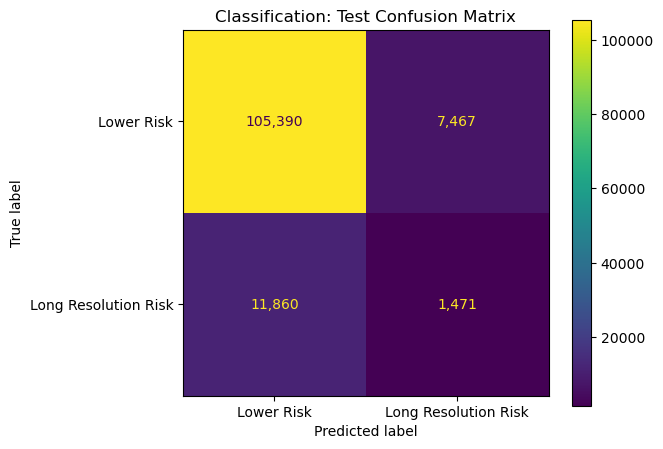

In [17]:
# Display the Test confusion matrix.
ConfusionMatrixDisplay.from_predictions(
    y_test_cls,
    test_cls_pred,
    display_labels=["Lower Risk", "Long Resolution Risk"],
    values_format=",",
)
plt.title("Classification: Test Confusion Matrix")
plt.tight_layout()
plt.show()

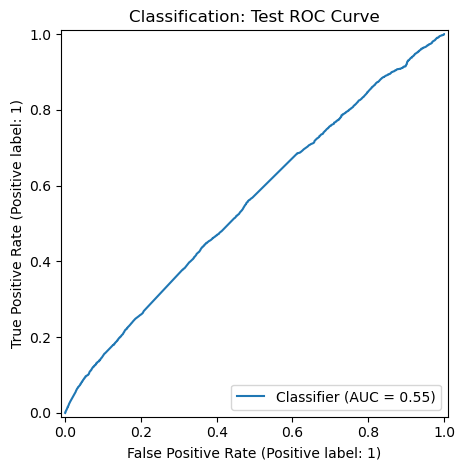

In [18]:
# Display the Test ROC curve.
RocCurveDisplay.from_predictions(
    y_test_cls,
    test_cls_probability,
)
plt.title("Classification: Test ROC Curve")
plt.tight_layout()
plt.show()

,feature,importance
1,created_year,0.2949
604,priority_Unknown,0.0936
13,project_key_AMBARI,0.0759
169,project_key_FLEX,0.0555
2,created_month,0.0451
496,project_key_STR,0.0333
620,issue_type_New Feature,0.0280
3,created_dayofweek,0.0276
502,project_key_SVN,0.0255
594,priority_Major,0.0152


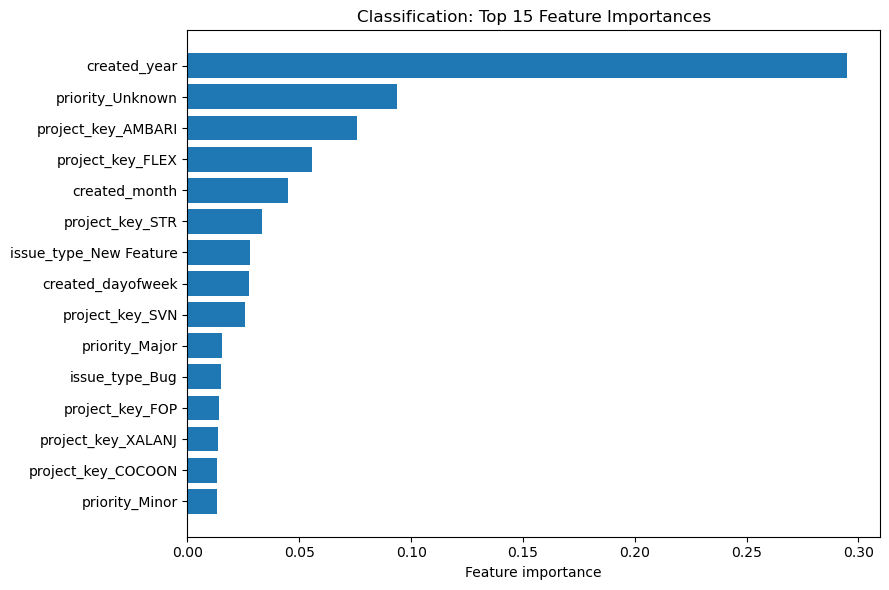

In [19]:
# Show the most important Classification features.
classification_importance = pd.DataFrame({
    "feature": SUPERVISED_FEATURES,
    "importance": classification_model.feature_importances_,
}).sort_values("importance", ascending=False)

display(classification_importance.head(15))

plt.figure(figsize=(9, 6))
top_classification_features = classification_importance.head(15).sort_values("importance")
plt.barh(top_classification_features["feature"], top_classification_features["importance"])
plt.xlabel("Feature importance")
plt.title("Classification: Top 15 Feature Importances")
plt.tight_layout()
plt.show()

In [20]:
# Save Test predictions and probabilities.
classification_test_results = pd.DataFrame({
    "task_key": test_ids.values,
    "actual_long_resolution_risk": y_test_cls.values,
    "predicted_long_resolution_risk": test_cls_pred,
    "risk_probability": test_cls_probability,
})

CLASSIFICATION_PREDICTIONS_PATH = RESULTS_DIR / "classification_test_predictions.csv"
classification_test_results.to_csv(CLASSIFICATION_PREDICTIONS_PATH, index=False)
print("Saved:", CLASSIFICATION_PREDICTIONS_PATH)

Saved: C:\Users\sadee\OneDrive\Desktop\ScaleFlow\ScaleFlow\ScaleFlow\AI_ML\Results\classification_test_predictions.csv


In [21]:
# Save the Classification model.
CLASSIFICATION_MODEL_PATH = MODELS_DIR / "random_forest_classification.joblib"
joblib.dump(classification_model, CLASSIFICATION_MODEL_PATH)
print("Saved:", CLASSIFICATION_MODEL_PATH)

# Free model memory before Isolation Forest.
del classification_model
gc.collect()

Saved: C:\Users\sadee\OneDrive\Desktop\ScaleFlow\ScaleFlow\ScaleFlow\AI_ML\Models\random_forest_classification.joblib


11828

<a id="section5"></a>
<h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">5. Isolation Forest — Potential Bottlenecks</h2>

<div style="background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;">
<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">5.1 Model definition</h3>
<table style="width:100%;border-collapse:collapse;margin-top:14px;">
<tr><th style="padding:9px;border:1px solid #CBD5E1;background-color:#0F766E;color:white;text-align:left;">Item</th><th style="padding:9px;border:1px solid #CBD5E1;background-color:#0F766E;color:white;text-align:left;">Value</th></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;">Problem type</td><td style="padding:9px;border:1px solid #CBD5E1;">Unsupervised Anomaly Detection</td></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;">Baseline model</td><td style="padding:9px;border:1px solid #CBD5E1;">Isolation Forest</td></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;">Target</td><td style="padding:9px;border:1px solid #CBD5E1;"><b>None</b></td></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;">Outputs</td><td style="padding:9px;border:1px solid #CBD5E1;"><code>anomaly_score</code>, <code>potential_bottleneck</code></td></tr>
</table>
<div style="background-color:#CCFBF1;color:#111827;padding:12px 14px;border-radius:8px;border:1px solid #CBD5E1;font-family:Consolas,'Courier New',monospace;font-size:0.98em;font-weight:600;line-height:1.6;white-space:pre-wrap;margin:12px 0;">Bottleneck-related features
        ↓
Isolation Forest
        ↓
Anomaly score
        ↓
Potential bottleneck</div>
<div style="border-left:5px solid #FBBF24;background-color:#FFFBEB;padding:11px 15px;margin:12px 0;border-radius:5px;color:#78350F;"><b>Important limitation:</b> The current bottleneck dataset contains historical lifecycle features such as <code>resolution_time_days</code> and <code>update_span_days</code>. This baseline identifies unusual historical task behavior; it is not yet a real-time early-warning model for open tasks.</div>
</div>

In [22]:
# Load only the columns needed for Bottleneck Detection.
bottleneck_usecols = [
    "task_key",
    "project_key",
    "created_date",
    *BOTTLENECK_FEATURES,
]

bottleneck_df = pd.read_csv(
    BOTTLENECK_PATH,
    usecols=bottleneck_usecols,
    low_memory=False,
)

print("Bottleneck dataset shape:", bottleneck_df.shape)
print("Missing values in model features:", bottleneck_df[BOTTLENECK_FEATURES].isna().sum().sum())
display(bottleneck_df[BOTTLENECK_FEATURES].describe().T)

Bottleneck dataset shape: (938948, 13)
Missing values in model features: 0


,count,mean,std,min,25%,50%,75%,max
resolution_time_days,"938,948.0000",201.9258,517.6950,0.0000,1.0429,11.7990,110.3168,"8,001.5173"
update_span_days,"938,948.0000",559.5356,938.7573,0.0000,10.5146,120.1188,681.3138,"8,414.6968"
issue_link_count,"938,948.0000",0.3582,1.0784,0.0000,0.0000,0.0000,0.0000,199.0000
dependency_count,"938,948.0000",0.0344,0.3998,0.0000,0.0000,0.0000,0.0000,199.0000
inward_link_count,"938,948.0000",0.1793,0.6332,0.0000,0.0000,0.0000,0.0000,114.0000
outward_link_count,"938,948.0000",0.1789,0.7509,0.0000,0.0000,0.0000,0.0000,198.0000
total_change_count,"938,948.0000",9.3242,19.9767,0.0000,2.0000,6.0000,11.0000,"2,962.0000"
status_change_count,"938,948.0000",1.5022,1.5681,0.0000,1.0000,1.0000,2.0000,100.0000
assignee_change_count,"938,948.0000",0.4623,0.7630,0.0000,0.0000,0.0000,1.0000,49.0000
reopen_count,"938,948.0000",0.0479,0.2381,0.0000,0.0000,0.0000,0.0000,10.0000


In [23]:
# Keep identifiers for the final report.
bottleneck_info = bottleneck_df[[
    "task_key",
    "project_key",
    "created_date",
]].copy()

# Isolation Forest uses only the prepared numerical bottleneck features.
X_bottleneck = bottleneck_df[BOTTLENECK_FEATURES].astype("float32")

assert X_bottleneck.isna().sum().sum() == 0
print("Isolation Forest input shape:", X_bottleneck.shape)

Isolation Forest input shape: (938948, 10)


In [24]:
# Train the unsupervised Isolation Forest.
# contamination='auto' avoids inventing a fixed bottleneck percentage.
isolation_forest_model = IsolationForest(
    n_estimators=200,
    max_samples="auto",
    contamination="auto",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print("Training Isolation Forest...")
isolation_forest_model.fit(X_bottleneck)
print("Isolation Forest training complete.")

Training Isolation Forest...
Isolation Forest training complete.


In [25]:
# Create the two requested outputs.
# score_samples gives lower values for more unusual rows.
# We reverse the sign so larger values mean more anomalous.
raw_anomaly_score = -isolation_forest_model.score_samples(X_bottleneck)

# Normalize the score to 0-1 for easier dashboard interpretation.
score_min = raw_anomaly_score.min()
score_max = raw_anomaly_score.max()

if score_max > score_min:
    anomaly_score = (raw_anomaly_score - score_min) / (score_max - score_min)
else:
    anomaly_score = np.zeros_like(raw_anomaly_score)

# Isolation Forest returns -1 for anomalies and 1 for normal observations.
isolation_prediction = isolation_forest_model.predict(X_bottleneck)
potential_bottleneck = (isolation_prediction == -1).astype("int8")

bottleneck_results = bottleneck_info.copy()
bottleneck_results["anomaly_score"] = anomaly_score
bottleneck_results["potential_bottleneck"] = potential_bottleneck

print("Potential bottlenecks:", f"{potential_bottleneck.sum():,}")
print(
    "Potential bottleneck rate:",
    f"{potential_bottleneck.mean() * 100:.2f}%",
)

Potential bottlenecks: 94,578
Potential bottleneck rate: 10.07%


In [26]:
# Review the tasks with the highest anomaly scores.
top_potential_bottlenecks = (
    bottleneck_results
    .sort_values("anomaly_score", ascending=False)
    .head(30)
)

display(top_potential_bottlenecks)

,task_key,project_key,created_date,anomaly_score,potential_bottleneck
298216,OAK-7182,OAK,2018-01-22 11:30:55,1.0000,1
288025,BEAM-2530,BEAM,2017-06-28 17:01:42,0.9994,1
542283,ZOOKEEPER-107,ZOOKEEPER,2008-07-29 23:02:56,0.9978,1
194852,IGNITE-2703,IGNITE,2016-02-20 13:03:50,0.9972,1
280518,MNG-624,MNG,2005-07-20 22:56:35,0.9911,1
296617,FLINK-18356,FLINK,2020-06-18 08:45:15,0.9867,1
405985,YARN-149,YARN,2012-06-17 09:07:34,0.9823,1
465453,HIVE-4570,HIVE,2013-05-16 08:32:10,0.9774,1
157938,HIVE-2206,HIVE,2011-06-08 08:38:30,0.9754,1
142477,HDFS-326,HDFS,2008-06-24 12:35:39,0.9747,1


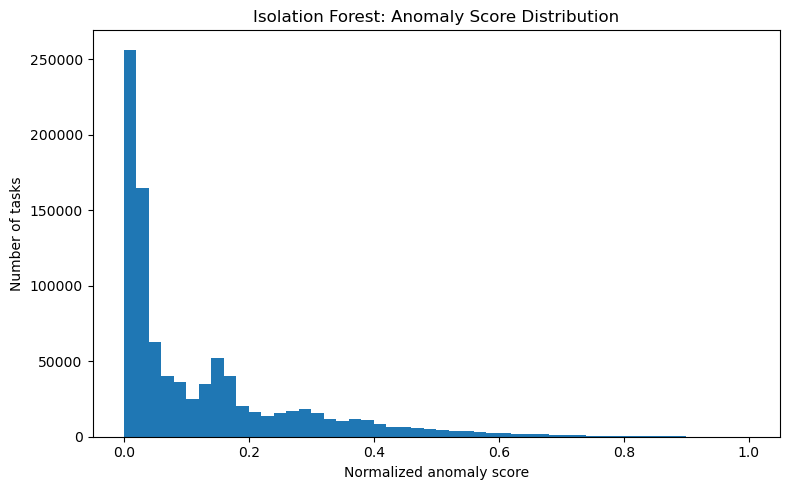

In [27]:
# Plot the anomaly-score distribution.
plt.figure(figsize=(8, 5))
plt.hist(bottleneck_results["anomaly_score"], bins=50)
plt.xlabel("Normalized anomaly score")
plt.ylabel("Number of tasks")
plt.title("Isolation Forest: Anomaly Score Distribution")
plt.tight_layout()
plt.show()

In [28]:
# Save Bottleneck Detection outputs.
BOTTLENECK_RESULTS_PATH = RESULTS_DIR / "bottleneck_predictions.csv"
TOP_BOTTLENECKS_PATH = RESULTS_DIR / "top_potential_bottlenecks.csv"
ISOLATION_MODEL_PATH = MODELS_DIR / "isolation_forest_bottleneck.joblib"

bottleneck_results.to_csv(BOTTLENECK_RESULTS_PATH, index=False)
top_potential_bottlenecks.to_csv(TOP_BOTTLENECKS_PATH, index=False)
joblib.dump(isolation_forest_model, ISOLATION_MODEL_PATH)

print("Saved:", BOTTLENECK_RESULTS_PATH)
print("Saved:", TOP_BOTTLENECKS_PATH)
print("Saved:", ISOLATION_MODEL_PATH)

Saved: C:\Users\sadee\OneDrive\Desktop\ScaleFlow\ScaleFlow\ScaleFlow\AI_ML\Results\bottleneck_predictions.csv
Saved: C:\Users\sadee\OneDrive\Desktop\ScaleFlow\ScaleFlow\ScaleFlow\AI_ML\Results\top_potential_bottlenecks.csv
Saved: C:\Users\sadee\OneDrive\Desktop\ScaleFlow\ScaleFlow\ScaleFlow\AI_ML\Models\isolation_forest_bottleneck.joblib


<a id="section6"></a>
<h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">6. Final Results Summary</h2>

<div style="background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;">
<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">6.1 How to read the three results</h3>
<table style="width:100%;border-collapse:collapse;margin-top:14px;">
<tr><th style="padding:9px;border:1px solid #CBD5E1;background-color:#0F766E;color:white;text-align:left;">Model</th><th style="padding:9px;border:1px solid #CBD5E1;background-color:#0F766E;color:white;text-align:left;">How it is evaluated</th></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;">Regression</td><td style="padding:9px;border:1px solid #CBD5E1;">Compare predicted duration with the numerical target using MAE, RMSE, and R².</td></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;">Classification</td><td style="padding:9px;border:1px solid #CBD5E1;">Compare predicted class/probability with the proxy target using classification metrics.</td></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;">Isolation Forest</td><td style="padding:9px;border:1px solid #CBD5E1;">No ground-truth target; review anomaly scores and highest-ranked potential bottlenecks.</td></tr>
</table>
<div style="border-left:5px solid #0284C7;background-color:#E0F2FE;padding:11px 15px;margin:12px 0;border-radius:5px;color:#0C4A6E;"><b>Important:</b> <code>potential_bottleneck</code> is a model output, not a true labeled target.</div>
</div>

In [29]:
# Build one readable summary for the three models.
results_summary = pd.DataFrame([
    {
        "Model": "Regression",
        "Target": REGRESSION_TARGET,
        "Main Validation Metric": "MAE",
        "Validation Value": regression_validation_metrics["MAE"],
        "Main Test Metric": "MAE",
        "Test Value": regression_test_metrics["MAE"],
    },
    {
        "Model": "Classification",
        "Target": CLASSIFICATION_TARGET,
        "Main Validation Metric": "F1",
        "Validation Value": classification_validation_metrics["F1"],
        "Main Test Metric": "F1",
        "Test Value": classification_test_metrics["F1"],
    },
    {
        "Model": "Isolation Forest",
        "Target": "None",
        "Main Validation Metric": "Manual validation",
        "Validation Value": np.nan,
        "Main Test Metric": "Potential bottleneck rate",
        "Test Value": potential_bottleneck.mean(),
    },
])

display(results_summary)

,Model,Target,Main Validation Metric,Validation Value,Main Test Metric,Test Value
0,Regression,resolution_time_days,MAE,222.4400,MAE,190.7673
1,Classification,long_resolution_risk,F1,0.1607,F1,0.1321
2,Isolation Forest,None,Manual validation,NaN,Potential bottleneck rate,0.1007


<a id="section7"></a>
<h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">7. Save Models & Handoff Files</h2>

<div style="background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;">
<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">7.1 Handoff outputs</h3>
<p>The notebook saves the trained baseline models, predictions, evaluation metrics, and a handoff JSON file inside the ScaleFlow AI/ML project structure.</p>
<div style="background-color:#CCFBF1;color:#111827;padding:12px 14px;border-radius:8px;border:1px solid #CBD5E1;font-family:Consolas,'Courier New',monospace;font-size:0.98em;font-weight:600;line-height:1.6;white-space:pre-wrap;margin:10px 0;">AI_ML/
├── Models/
│   ├── random_forest_regression.joblib
│   ├── random_forest_classification.joblib
│   └── isolation_forest_bottleneck.joblib
└── Results/
    ├── regression_test_predictions.csv
    ├── classification_test_predictions.csv
    ├── bottleneck_predictions.csv
    ├── top_potential_bottlenecks.csv
    ├── model_evaluation_metrics.json
    └── model_handoff.json</div>
<div style="border-left:5px solid #0F766E;background-color:#CCFBF1;padding:10px 15px;margin:10px 0;border-radius:4px;color:#134E4A;"><b>Why this matters:</b> The next developer can load the saved models and use the recorded feature lists without repeating the training notebook.</div>
</div>

In [30]:
# Save all evaluation metrics in one JSON file for the next developer.
metrics_output = {
    "regression": {
        "target": REGRESSION_TARGET,
        "validation": {k: float(v) for k, v in regression_validation_metrics.items()},
        "test": {k: float(v) for k, v in regression_test_metrics.items()},
    },
    "classification": {
        "target": CLASSIFICATION_TARGET,
        "validation": {k: float(v) for k, v in classification_validation_metrics.items()},
        "test": {k: float(v) for k, v in classification_test_metrics.items()},
    },
    "bottleneck_isolation_forest": {
        "target": None,
        "rows_scored": int(len(bottleneck_results)),
        "potential_bottlenecks": int(potential_bottleneck.sum()),
        "potential_bottleneck_rate": float(potential_bottleneck.mean()),
        "output_columns": ["anomaly_score", "potential_bottleneck"],
    },
}

METRICS_PATH = RESULTS_DIR / "baseline_model_metrics.json"
with open(METRICS_PATH, "w", encoding="utf-8") as file:
    json.dump(metrics_output, file, indent=2)

print("Saved:", METRICS_PATH)

Saved: C:\Users\sadee\OneDrive\Desktop\ScaleFlow\ScaleFlow\ScaleFlow\AI_ML\Results\baseline_model_metrics.json


In [31]:
# Save a simple handoff file that explains how each saved model should be used.
handoff = {
    "supervised_feature_count": len(SUPERVISED_FEATURES),
    "supervised_features": SUPERVISED_FEATURES,
    "regression": {
        "model_file": REGRESSION_MODEL_PATH.name,
        "target": REGRESSION_TARGET,
        "prediction_meaning": "Predicted resolution time in days",
    },
    "classification": {
        "model_file": CLASSIFICATION_MODEL_PATH.name,
        "target": CLASSIFICATION_TARGET,
        "prediction_meaning": "Long resolution risk proxy (0 or 1) and probability",
        "risk_threshold_days": metadata.get("risk_threshold_days"),
    },
    "bottleneck_isolation_forest": {
        "model_file": ISOLATION_MODEL_PATH.name,
        "target": None,
        "features": BOTTLENECK_FEATURES,
        "prediction_outputs": ["anomaly_score", "potential_bottleneck"],
        "note": "potential_bottleneck is a model output, not a ground-truth label",
    },
}

HANDOFF_PATH = RESULTS_DIR / "model_handoff.json"
with open(HANDOFF_PATH, "w", encoding="utf-8") as file:
    json.dump(handoff, file, indent=2)

print("Saved:", HANDOFF_PATH)

Saved: C:\Users\sadee\OneDrive\Desktop\ScaleFlow\ScaleFlow\ScaleFlow\AI_ML\Results\model_handoff.json


In [32]:
# Show the final output inventory.
output_files = [
    REGRESSION_MODEL_PATH,
    CLASSIFICATION_MODEL_PATH,
    ISOLATION_MODEL_PATH,
    REGRESSION_PREDICTIONS_PATH,
    CLASSIFICATION_PREDICTIONS_PATH,
    BOTTLENECK_RESULTS_PATH,
    TOP_BOTTLENECKS_PATH,
    METRICS_PATH,
    HANDOFF_PATH,
]

output_inventory = []
for path in output_files:
    output_inventory.append({
        "file": path.name,
        "folder": path.parent.name,
        "exists": path.exists(),
        "size_mb": round(path.stat().st_size / (1024 ** 2), 2) if path.exists() else None,
    })

display(pd.DataFrame(output_inventory))

,file,folder,exists,size_mb
0,random_forest_regression.joblib,Models,True,22.7000
1,random_forest_classification.joblib,Models,True,37.8700
2,isolation_forest_bottleneck.joblib,Models,True,1.4200
3,regression_test_predictions.csv,Results,True,5.0000
4,classification_test_predictions.csv,Results,True,4.3400
5,bottleneck_predictions.csv,Results,True,54.5400
6,top_potential_bottlenecks.csv,Results,True,0.0000
7,baseline_model_metrics.json,Results,True,0.0000
8,model_handoff.json,Results,True,0.0200


<a id="section8"></a>
<h2 style="color:#FFFFFF;background:linear-gradient(90deg,#0F766E,#0284C7);font-weight:bold;margin-top:30px;padding:10px 15px;border-radius:8px;">8. Task Definition of Done</h2>

<div style="background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;">
<table style="width:100%;border-collapse:collapse;margin-top:14px;">
<tr><th style="padding:9px;border:1px solid #CBD5E1;background-color:#0F766E;color:white;text-align:left;vertical-align:top;">Task requirement</th><th style="padding:9px;border:1px solid #CBD5E1;background-color:#0F766E;color:white;text-align:left;vertical-align:top;">How this notebook completes it</th></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;">Regression baseline</td><td style="padding:9px;border:1px solid #CBD5E1;">Random Forest Regressor trained for <code>resolution_time_days</code>.</td></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;">Regression evaluation</td><td style="padding:9px;border:1px solid #CBD5E1;">MAE, RMSE, and R² calculated on Validation and Test.</td></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;">Classification baseline</td><td style="padding:9px;border:1px solid #CBD5E1;">Random Forest Classifier trained for <code>long_resolution_risk</code>.</td></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;">Classification evaluation</td><td style="padding:9px;border:1px solid #CBD5E1;">Accuracy, Precision, Recall, F1, ROC-AUC, and Confusion Matrix.</td></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;">Bottleneck baseline</td><td style="padding:9px;border:1px solid #CBD5E1;">Isolation Forest trained without a supervised target.</td></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;">Bottleneck outputs</td><td style="padding:9px;border:1px solid #CBD5E1;"><code>anomaly_score</code> and <code>potential_bottleneck</code> exported.</td></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;">Reproducible handoff</td><td style="padding:9px;border:1px solid #CBD5E1;">Models, predictions, metrics, and handoff metadata are saved.</td></tr>
</table>
<div style="font-size:1.12em;font-weight:bold;text-align:center;background-color:#FFFBEB;border:1px solid #FBBF24;padding:16px;border-radius:8px;margin:14px 0;color:#111827;">Prepared ScaleFlow Data → Regression + Classification + Isolation Forest → Evaluation → Saved Models → Handoff</div>
</div>

<div style="text-align:center;margin-top:28px;color:#475569;">
<b>End of ScaleFlow — Train & Evaluate ML Baseline Models</b><br>
Three-model scope only: Regression • Classification • Isolation Forest
</div>